# Проектная работа: Машинное обучение в бизнесе 

## Описание проекта
Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину. 
Шаги для выбора локации обычно такие:
* 		В избранном регионе собирают характеристики для скважин: качество нефти и объём её запасов;
* 		Строят модель для предсказания объёма запасов в новых скважинах;
* 		Выбирают скважины с самыми высокими оценками значений;
* 		Определяют регион с максимальной суммарной прибылью отобранных скважин.
Вам предоставлены пробы нефти в трёх регионах. Характеристики для каждой скважины в регионе уже известны. Постройте модель для определения региона, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой Bootstrap.

## Цель исследования

1. Построить и сравнить модели линейной регрессии для **прогноза объёма запасов нефти** (`product`) по данным трёх регионов. Критерий успеха: **минимальный RMSE** на валидационной выборке.
2. Рассчитать **прибыль и риски** разработки региона на основе предсказаний модели. Критерий успеха: **максимальная средняя прибыль при риске убытков < 2.5%**.
3. Сравнить регионы по результатам и **выбрать оптимальный регион** для бурения новых скважин.
4. Проверить **безубыточный объём добычи** и сопоставить его со средними запасами по регионам.
5. Обеспечить **воспроизводимость и чистоту эксперимента**: использовать фиксированный `random_state`, единые параметры для всех регионов, отсутствие утечек данных между train и valid.







### Этапы исследования

1. **Обзор и подготовка данных**

2. **Обучение моделей линейной регрессии**

   * Разделение на обучающую и валидационную выборки (75/25).
   * Обучение и предсказание на валидации.
   * Оценка метрики RMSE и среднего предсказанного запаса.

3. **Подготовка к расчёту прибыли**

   * Определение ключевых констант: бюджет, цена барреля, число скважин.
   * Расчёт безубыточного объёма и сравнение с средними предсказанными запасами.

4. **Расчёт прибыли**

   * Функция для выбора 200 лучших скважин по предсказаниям и вычисления прибыли.
   * Применение функции к каждому региону.

5. **Оценка рисков методом Bootstrap (1000 итераций)**

   * Расчёт распределения прибыли, доверительного интервала и вероятности убытков.
   * Сравнение регионов по средней прибыли и риску.

6. **Выводы и рекомендации**

   * Выбор региона с максимальной прибылью при риске < 2.5%.
   * Обоснование решения.


##  Загрузка и изучение данных
### Импорты и настройки окружения
Так как в исходной среде платформы использовались устаревшие версии библиотек, в начале проекта я обновляла `scikit-learn`, `numpy` и `pandas`. Это позволило работать в более актуальном и согласованном окружении.

In [1]:
#!pip install -U scikit-learn numpy pandas


In [2]:
# === Импорты ===

import pandas as pd
import numpy as np
import sklearn

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns


import random
import math

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Сoxраним графику
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

def save_plot(name: str, dpi: int = 300):
    plt.tight_layout()
    plt.savefig(IMG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"Saved: {IMG_DIR / f'{name}.png'}")


In [3]:
print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

sklearn: 1.6.1
numpy: 2.1.3
pandas: 2.3.1


### Загрузка исходных данных

Загружу данные по трём регионам. Так как проект может запускаться в разных средах, предусмотрю несколько возможных путей к файлам.

In [4]:
# Возможные пути, где могут находиться датасеты
BASE_DIRS = [Path("/datasets"), Path("../datasets"), Path("datasets"), Path("../data"), Path("data"), Path(".")]

FILES = {
    "geo_0": "geo_data_0.csv",
    "geo_1": "geo_data_1.csv",
    "geo_2": "geo_data_2.csv",
}

data_dir = next((path for path in BASE_DIRS if all((path / file).exists() for file in FILES.values())), None)

if data_dir is None:
    raise FileNotFoundError("Не удалось найти датасеты ни в одной из стандартных папок")

dfs = {name: pd.read_csv(data_dir / filename) for name, filename in FILES.items()}

for name, df in dfs.items():
    print(f"{name}: {data_dir / FILES[name]} — shape={df.shape}")

geo_0, geo_1, geo_2 = (dfs[name] for name in ("geo_0", "geo_1", "geo_2"))

geo_0: ../data/geo_data_0.csv — shape=(100000, 5)
geo_1: ../data/geo_data_1.csv — shape=(100000, 5)
geo_2: ../data/geo_data_2.csv — shape=(100000, 5)


После загрузки данных перехожу к их первичному обзору и проверке качества.

### Первичный обзор данных
На этом этапе проверю:
- размер таблиц;
- типы данных;
- первые строки;
- основные статистики;
- наличие пропусков и дубликатов.

In [5]:
for name, df in dfs.items():
    if df is not None:
        print("=" * 60)
        print(f"{name.upper()} — первые строки")
        display(df.head())

        print(f"{name.upper()} — общая информация")
        df.info()

        print(f"{name.upper()} — описательная статистика")
        display(df.describe())

GEO_0 — первые строки


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


GEO_0 — общая информация
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
GEO_0 — описательная статистика


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


GEO_1 — первые строки


...

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


GEO_2 — первые строки


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


GEO_2 — общая информация
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
GEO_2 — описательная статистика


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


In [6]:
for name, df in dfs.items():
    if df is not None:
        print("=" * 60)
        print(f"{name.upper()} — пропуски")
        print(df.isna().sum())

        print(f"{name.upper()} — полные дубликаты")
        print(df.duplicated().sum())

        print(f"{name.upper()} — дубликаты id")
        print(df["id"].duplicated().sum())

GEO_0 — пропуски
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
GEO_0 — полные дубликаты
0
GEO_0 — дубликаты id
10
GEO_1 — пропуски
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
GEO_1 — полные дубликаты
0
GEO_1 — дубликаты id
4
GEO_2 — пропуски
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
GEO_2 — полные дубликаты
0
GEO_2 — дубликаты id
4


В рамках данного проекта не буду проводить углублённый исследовательский анализ признаков с большим количеством визуализаций, так как данные синтетические, а признаки `f0`, `f1`, `f2` не имеют содержательной интерпретации. Для решения задачи достаточно проверить структуру данных, отсутствие пропусков и корректность типов, после чего перейти к обучению модели и расчёту бизнес-метрик.

### Распределение целевого признака 

Дополнительно рассмотрю распределение целевого признака `product` в каждом регионе. Это позволит сравнить характер запасов сырья и выявить особенности, которые могут повлиять на качество предсказаний модели и последующую оценку прибыли.

Saved: ../images/product_distribution_geo_0.png


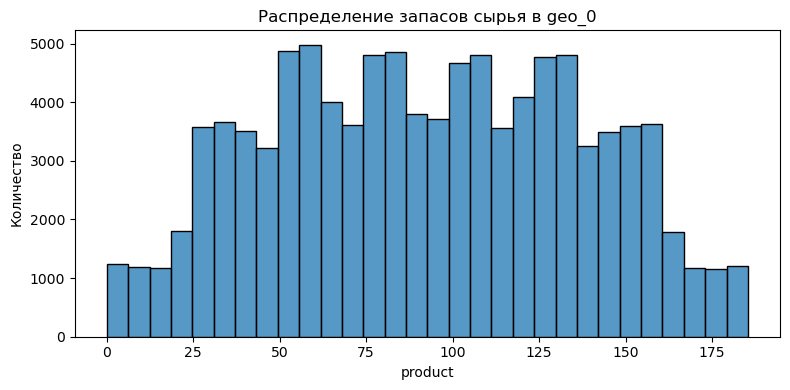

Saved: ../images/product_distribution_geo_1.png


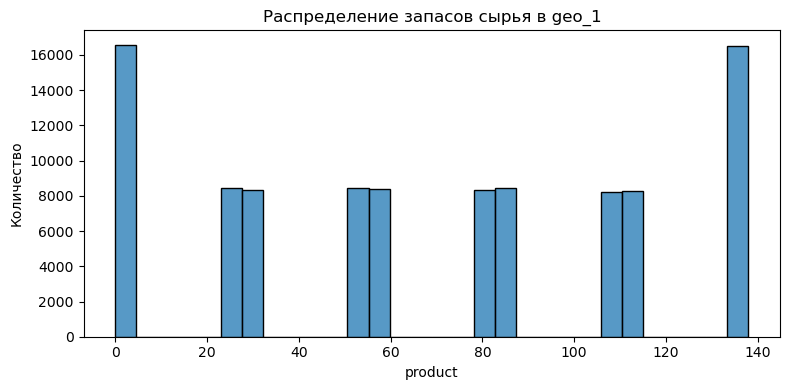

Saved: ../images/product_distribution_geo_2.png


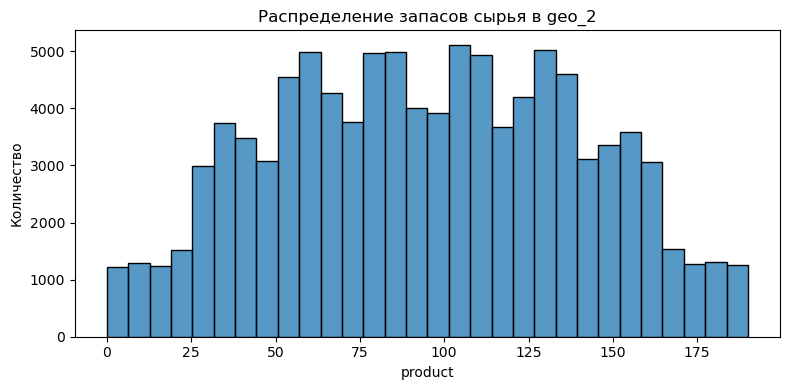

In [7]:
for name, df in dfs.items():
    if df is not None:
        plt.figure(figsize=(8, 4))
        sns.histplot(df['product'], bins=30)
        plt.title(f'Распределение запасов сырья в {name}')
        plt.xlabel('product')
        plt.ylabel('Количество')
        save_plot(f'product_distribution_{name}')
        plt.show()

По распределениям целевого признака видно, что регионы различаются.

- Для `geo_0` и `geo_2` распределения выглядят достаточно широкими и близкими по форме: значения `product` распределены по большому диапазону, без явных выбросов и резких разрывов.
- Для `geo_1` распределение имеет выраженный дискретный характер: значения концентрируются в нескольких отдельных точках. Это заметно отличает второй регион от двух остальных.
- Явных аномалий, которые мешали бы дальнейшему моделированию, не наблюдается, однако особенности распределения в `geo_1` могут повлиять на качество предсказаний и итоговые бизнес-метрики.

Далее можно перейти к обучению модели линейной регрессии и сравнению регионов по качеству прогноза.

Особенно выделяется регион `geo_1`: распределение запасов в нём не похоже на два остальных региона и имеет ступенчатую структуру. Это может сказаться как на точности модели, так и на итоговой оценке прибыли, поэтому далее результаты по регионам важно сравнивать отдельно.

### Анализ взаимосвязи признаков и мультиколлинеарности

Дополнительно проанализирую взаимосвязь числовых признаков и целевого признака. Для этого рассмотрю корреляционные матрицы и диаграммы рассеяния. Такой анализ позволяет оценить наличие сильных линейных зависимостей между признаками и выявить возможные признаки мультиколлинеарности.

In [8]:
for name, df in dfs.items():
    if df is not None:
        print(f'\n{name.upper()} — корреляционная матрица')
        display(df[['f0', 'f1', 'f2', 'product']].corr())


GEO_0 — корреляционная матрица


,f0,f1,f2,product
f0,1.000000,-0.440723,-0.003153,0.143536
f1,-0.440723,1.000000,0.001724,-0.192356
f2,-0.003153,0.001724,1.000000,0.483663
product,0.143536,-0.192356,0.483663,1.000000



GEO_1 — корреляционная матрица


,f0,f1,f2,product
f0,1.000000,0.182287,-0.001777,-0.030491
f1,0.182287,1.000000,-0.002595,-0.010155
f2,-0.001777,-0.002595,1.000000,0.999397
product,-0.030491,-0.010155,0.999397,1.000000



GEO_2 — корреляционная матрица


,f0,f1,f2,product
f0,1.000000,0.000528,-0.000448,-0.001987
f1,0.000528,1.000000,0.000779,-0.001012
f2,-0.000448,0.000779,1.000000,0.445871
product,-0.001987,-0.001012,0.445871,1.000000


Для анализа взаимосвязи признаков с целевым признаком построю отдельные диаграммы рассеяния для каждой пары `признак — product`. Такой формат позволяет более наглядно рассмотреть зависимость целевого признака от каждого из факторов по регионам.

Saved: ../images/feature_product_scatter_geo_0.png


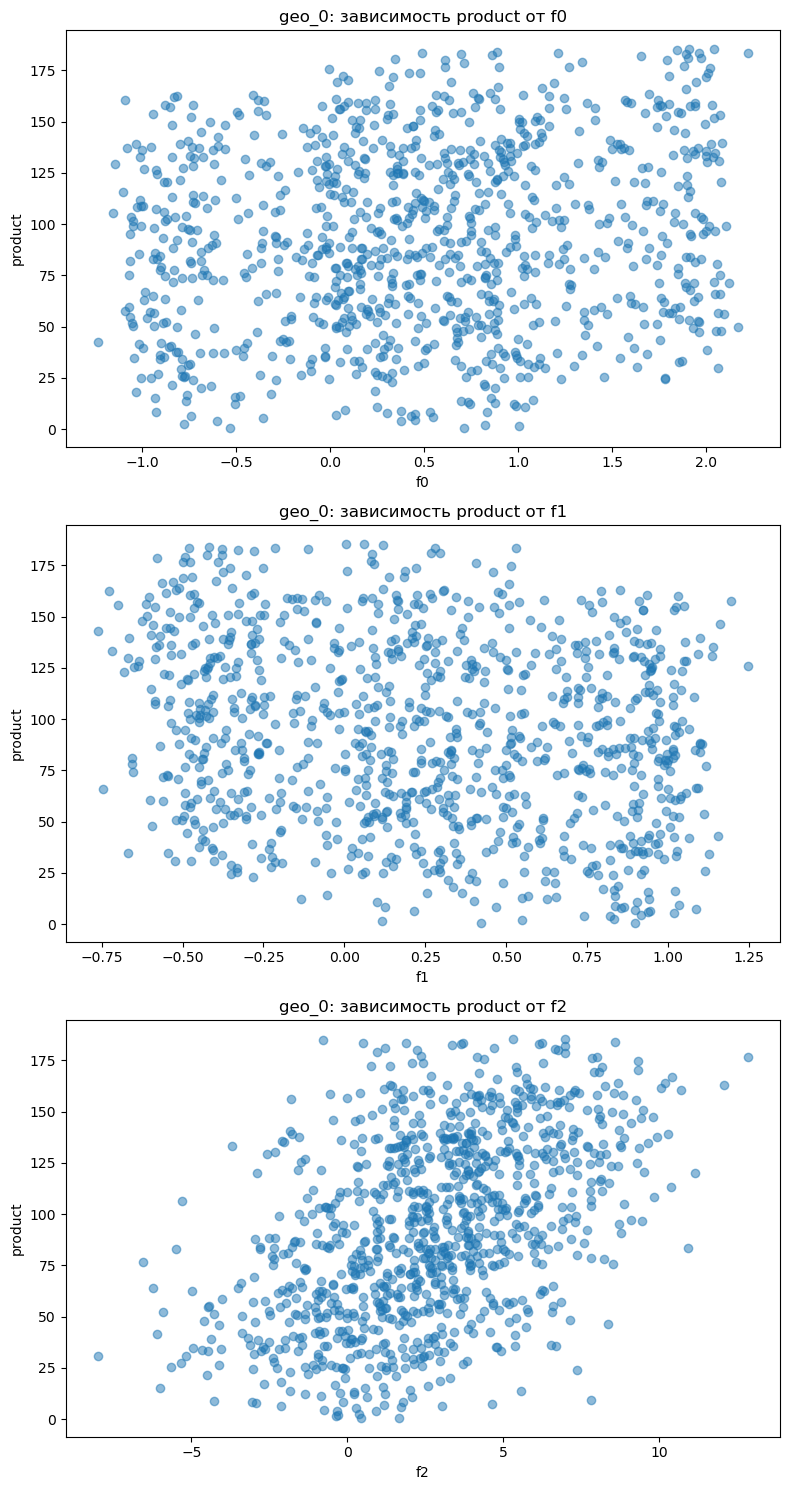

Saved: ../images/feature_product_scatter_geo_1.png


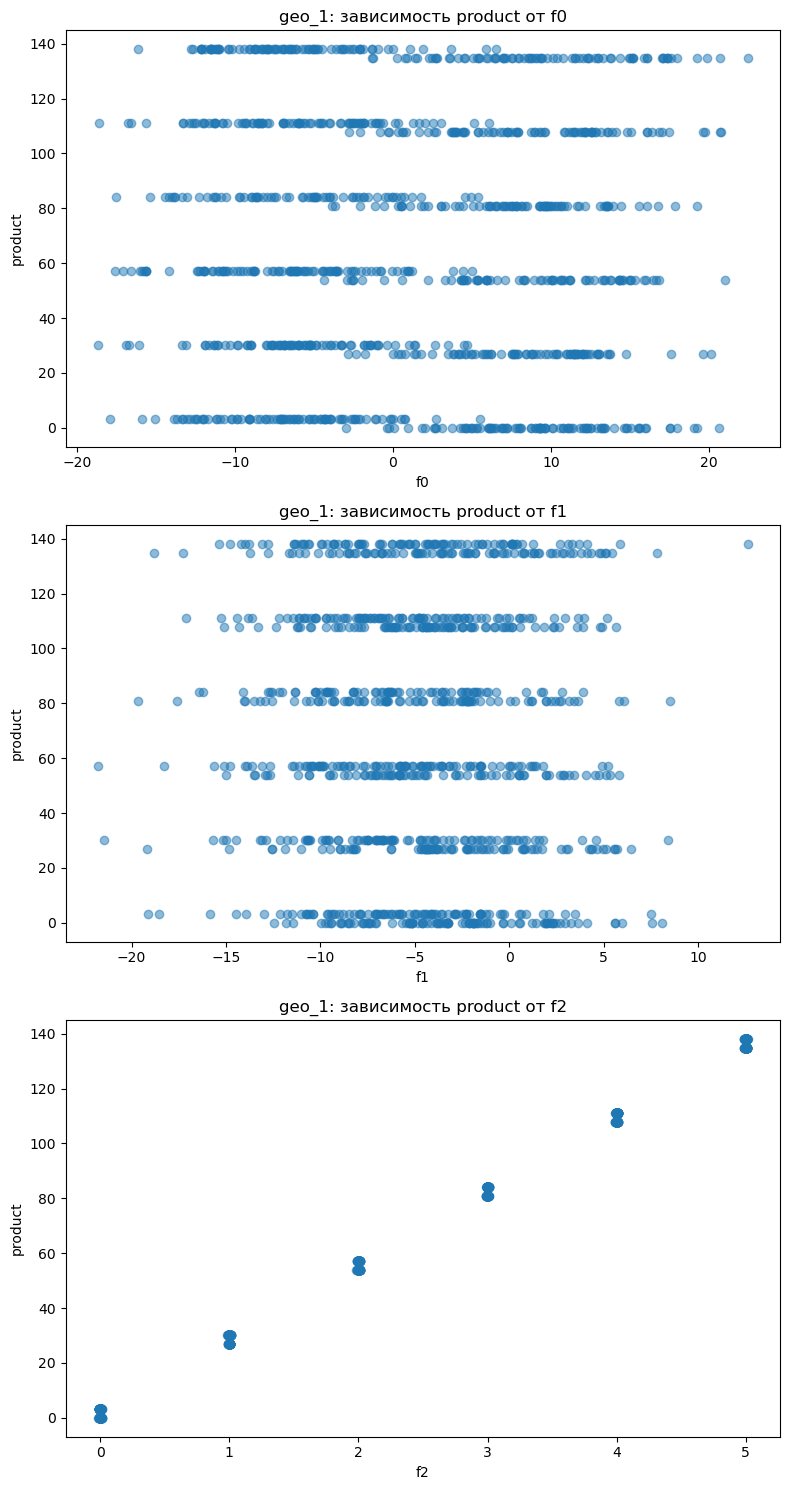

Saved: ../images/feature_product_scatter_geo_2.png


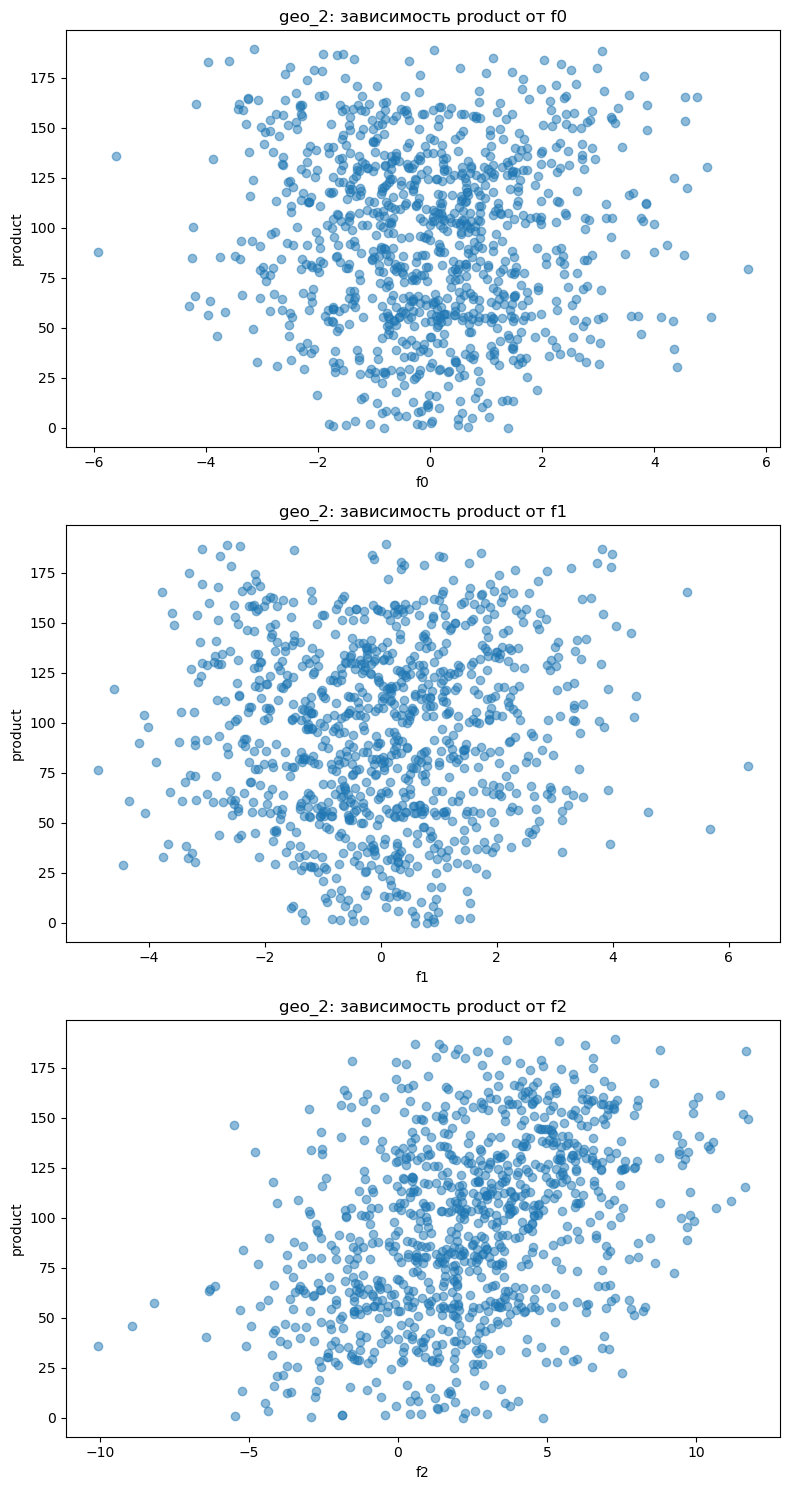

In [9]:
for name, df in dfs.items():
    if df is not None:
        sample_df = df[['f0', 'f1', 'f2', 'product']].sample(1000, random_state=RANDOM_STATE)

        fig, axes = plt.subplots(3, 1, figsize=(8, 15))

        axes[0].scatter(sample_df['f0'], sample_df['product'], alpha=0.5)
        axes[0].set_title(f'{name}: зависимость product от f0')
        axes[0].set_xlabel('f0')
        axes[0].set_ylabel('product')

        axes[1].scatter(sample_df['f1'], sample_df['product'], alpha=0.5)
        axes[1].set_title(f'{name}: зависимость product от f1')
        axes[1].set_xlabel('f1')
        axes[1].set_ylabel('product')

        axes[2].scatter(sample_df['f2'], sample_df['product'], alpha=0.5)
        axes[2].set_title(f'{name}: зависимость product от f2')
        axes[2].set_xlabel('f2')
        axes[2].set_ylabel('product')

        plt.tight_layout()
        save_plot(f'feature_product_scatter_{name}')
        plt.show()

По корреляционному анализу и диаграммам рассеяния можно сделать вывод, что структура взаимосвязей между признаками различается по регионам. Сильной мультиколлинеарности между признаками `f0`, `f1` и `f2`, которая могла бы критически исказить дальнейшее моделирование, не выявлено. При этом в отдельных регионах наблюдаются более выраженные связи между признаками и целевым признаком `product`, что может объяснять различия в качестве предсказаний модели.


###  Вывод по данным

На этапе загрузки и первичного изучения данных были проанализированы три датасета по регионам добычи.

- Все три набора данных успешно загружены и имеют одинаковую структуру: содержат идентификатор скважины `id`, три числовых признака `f0`, `f1`, `f2` и целевой признак `product`.
- Типы данных заданы корректно, пропуски отсутствуют, поэтому дополнительная обработка пропущенных значений не требуется.
- Полных дубликатов в данных нет. Возможные повторения идентификаторов `id` не критичны для задачи, так как этот столбец не будет использоваться в обучении модели.
- Описательная статистика показывает, что признаки и целевой признак имеют адекватные диапазоны значений, явных аномалий на данном этапе не обнаружено.
- Анализ распределения целевого признака `product` показал, что регионы различаются по характеру запасов сырья. Для `geo_0` и `geo_2` распределения выглядят схожими и более непрерывными, тогда как для `geo_1` наблюдается выраженная дискретность значений.

В целом данные выглядят корректными и пригодными для дальнейшего анализа. Можно переходить к обучению моделей линейной регрессии и сравнению регионов по качеству предсказаний.

## Обучение и проверка модели

В соответствии с условием задачи для каждого региона обучу модель линейной регрессии.
Данные будут разделены на обучающую и валидационную выборки в соотношении 75:25.
Качество модели оценю с помощью метрики RMSE, а также сравню средний предсказанный объём запасов сырья.


В данном проекте дополнительное масштабирование признаков не выполнялось. Для решения задачи используется модель `LinearRegression`, качество предсказаний которой при линейном преобразовании признаков, как правило, существенно не меняется. Поскольку признаки уже представлены в числовом виде, а цель исследования состоит в сравнении регионов по качеству прогноза, прибыли и рискам, усложнять пайплайн дополнительной стандартизацией не требуется.

###  Функция обучения и валидации модели

Для каждого региона необходимо выполнить одинаковую последовательность действий: выделить признаки и целевой признак, разделить данные на обучающую и валидационную выборки в соотношении 75:25, обучить модель линейной регрессии и получить предсказания на валидационной выборке.

Чтобы не дублировать код, подготовлю отдельную функцию. Она будет возвращать:
- истинные значения целевого признака на валидационной выборке;
- предсказания модели;
- средний предсказанный объём запасов сырья;
- значение RMSE.


In [10]:
def train_and_evaluate_region(df):
    """
    Обучает модель линейной регрессии для одного региона,
    возвращает истинные и предсказанные значения,
    средний предсказанный запас и RMSE.
    """
    
    features = df[['f0', 'f1', 'f2']]
    target = df['product']
    
    X_train, X_valid, y_train, y_valid = train_test_split(
        features,
        target,
        test_size=0.25,
        random_state=RANDOM_STATE
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_valid)
    mean_predicted = predictions.mean()
    rmse = mean_squared_error(y_valid, predictions) ** 0.5
    
    return y_valid, predictions, mean_predicted, rmse

### Обучение модели для каждого региона

Применю подготовленную функцию к данным каждого региона. Для каждого набора данных отдельно получу предсказания на валидационной выборке, средний предсказанный объём запасов и значение RMSE. Это позволит сравнить качество модели между регионами на одинаковых условиях.

In [11]:
results = {}

for name, df in dfs.items():
    if df is not None:
        y_valid, predictions, mean_predicted, rmse = train_and_evaluate_region(df)
        
        results[name] = {
            'y_valid': y_valid,
            'predictions': predictions,
            'mean_predicted': mean_predicted,
            'rmse': rmse
        }
        
        print(f'{name}:')
        print(f'Средний предсказанный запас: {mean_predicted:.2f}')
        print(f'RMSE: {rmse:.2f}')
        print()

geo_0:
Средний предсказанный запас: 92.40
RMSE: 37.76

geo_1:
Средний предсказанный запас: 68.71
RMSE: 0.89

geo_2:
Средний предсказанный запас: 94.77
RMSE: 40.15



### Оценка качества моделей

Сведу результаты обучения в общую таблицу и сравню модели по двум ключевым показателям:
- среднему предсказанному объёму запасов сырья;
- значению RMSE на валидационной выборке.

Средний предсказанный объём позволяет оценить общий уровень прогнозируемых запасов в регионе, а RMSE показывает, насколько точно модель предсказывает фактические значения.

In [12]:
results_summary = pd.DataFrame({
    'Регион': results.keys(),
    'Средний предсказанный запас, тыс. баррелей': [result['mean_predicted'] for result in results.values()],
    'RMSE': [result['rmse'] for result in results.values()]
})

results_summary['Средний предсказанный запас, тыс. баррелей'] = results_summary['Средний предсказанный запас, тыс. баррелей'].round(2)
results_summary['RMSE'] = results_summary['RMSE'].round(2)

results_summary

,Регион,"Средний предсказанный запас, тыс. баррелей",RMSE
0,geo_0,92.40,37.76
1,geo_1,68.71,0.89
2,geo_2,94.77,40.15


### Вывод по качеству моделей

По результатам обучения и проверки моделей были получены следующие значения:

- для региона `geo_0` средний предсказанный запас составил **92.40 тыс. баррелей**, RMSE — **37.76**;
- для региона `geo_1` средний предсказанный запас составил **68.71 тыс. баррелей**, RMSE — **0.89**;
- для региона `geo_2` средний предсказанный запас составил **94.77 тыс. баррелей**, RMSE — **40.15**.

Наиболее точной модель оказалась для региона `geo_1`, поскольку здесь получено минимальное значение RMSE. Это означает, что предсказания модели в данном регионе наиболее близки к фактическим значениям.

При этом средний предсказанный объём запасов в регионе `geo_1` ниже, чем в регионах `geo_0` и `geo_2`. Наибольший средний прогнозируемый запас наблюдается в регионе `geo_2`, однако для него же получено и наибольшее значение RMSE.

Таким образом, регионы различаются как по среднему прогнозируемому объёму запасов, так и по точности модели. Для окончательного выбора региона необходимо перейти к расчёту прибыли и оценке рисков.

## Подготовка к расчёту прибыли

На этом этапе задам основные бизнес-константы проекта и рассчитаю минимальный объём сырья, необходимый для безубыточной разработки одной скважины. Затем сравню этот порог со средними предсказанными запасами по регионам.

### Бизнес-константы проекта

Для расчёта прибыли задам основные параметры задачи, указанные в условии:
- количество исследуемых точек в регионе — `500`;
- количество лучших скважин, отбираемых для разработки, — `200`;
- бюджет на разработку одного региона — `10 млрд рублей`;
- доход с одной единицы продукта — `450 тыс. рублей`, так как объём запасов указан в тысячах баррелей.

Эти значения будут использоваться на следующих этапах при расчёте безубыточного объёма, прибыли и рисков.

In [13]:
# бизнес-константы
BUDGET = 10_000_000_000          # бюджет на разработку региона, руб.
REVENUE_PER_UNIT = 450_000       # доход с 1 тыс. баррелей, руб.
TOTAL_POINTS = 500               # количество исследуемых точек
TOP_WELLS = 200                  # количество лучших скважин для разработки

print(f'Бюджет на регион: {BUDGET:,} руб.')
print(f'Доход с 1 тыс. баррелей: {REVENUE_PER_UNIT:,} руб.')
print(f'Количество исследуемых точек: {TOTAL_POINTS}')
print(f'Количество скважин для разработки: {TOP_WELLS}')

Бюджет на регион: 10,000,000,000 руб.
Доход с 1 тыс. баррелей: 450,000 руб.
Количество исследуемых точек: 500
Количество скважин для разработки: 200


### Расчёт безубыточного объёма сырья

Рассчитаю минимальный объём сырья, необходимый для безубыточной разработки одной скважины. Для этого разделю общий бюджет региона на количество скважин, выбранных для разработки, а затем определю, какой объём запасов должен приходиться на одну скважину, чтобы выручка покрывала затраты.

Полученный порог позволит оценить, насколько средние прогнозные запасы по регионам соответствуют условиям безубыточной разработки.

In [14]:
# безубыточный объём сырья на одну скважину
break_even_volume = BUDGET / TOP_WELLS / REVENUE_PER_UNIT

print(f'Безубыточный объём сырья на одну скважину: {break_even_volume:.2f} тыс. баррелей')

Безубыточный объём сырья на одну скважину: 111.11 тыс. баррелей


### Сравнение безубыточного порога со средними запасами

Сравню рассчитанный безубыточный объём сырья на одну скважину со средним предсказанным объёмом запасов в каждом регионе. Это позволит предварительно оценить, насколько регионы выглядят перспективными с точки зрения экономики проекта ещё до применения Bootstrap.

In [15]:
comparison_df = results_summary.copy()

comparison_df['Безубыточный объём, тыс. баррелей'] = round(break_even_volume, 2)
comparison_df['Разница'] = (
	comparison_df['Средний предсказанный запас, тыс. баррелей'] - comparison_df['Безубыточный объём, тыс. баррелей']
).round(2)

comparison_df

,Регион,"Средний предсказанный запас, тыс. баррелей",RMSE,"Безубыточный объём, тыс. баррелей",Разница
0,geo_0,92.40,37.76,111.11,-18.71
1,geo_1,68.71,0.89,111.11,-42.40
2,geo_2,94.77,40.15,111.11,-16.34


### Вывод по этапу подготовки

Расчёт показал, что для безубыточной разработки одной скважины необходим средний объём сырья **111.11 тыс. баррелей**.

Сравнение этого порога со средними предсказанными запасами по регионам показало, что ни в одном из регионов среднее прогнозируемое значение не достигает уровня безубыточности:

- для `geo_0` отклонение составляет **-18.71 тыс. баррелей**;
- для `geo_1` — **-42.40 тыс. баррелей**;
- для `geo_2` — **-16.34 тыс. баррелей**.

Наиболее близким к безубыточному порогу оказался регион `geo_2`, затем `geo_0`. Наименее перспективным по этому показателю выглядит регион `geo_1`.

Однако данный расчёт основан только на средних значениях. Поскольку по условию задачи для разработки будут выбираться не все скважины, а только 200 лучших из 500, окончательное решение нельзя принимать на этом этапе. Далее необходимо рассчитать прибыль по отобранным скважинам и оценить риск убытков с помощью Bootstrap.


## Расчёт прибыли

Далее рассчитаю прибыль по отобранным скважинам. По условию задачи для разработки выбираются 200 скважин с максимальными предсказанными значениями объёма сырья. Прибыль будет рассчитываться по фактическим значениям целевого признака для этих скважин с учётом общего бюджета региона.

### Функция расчёта прибыли

Подготовлю функцию для расчёта прибыли по выбранным скважинам. Она будет сортировать скважины по предсказанным значениям объёма сырья, отбирать 200 лучших, суммировать их фактические запасы и на основе этого рассчитывать итоговую прибыль с учётом бюджета региона.

Такой подход соответствует условию задачи: решение о выборе скважин принимается по прогнозу модели, а прибыль рассчитывается по реальным значениям целевого признака.

In [16]:
def calculate_profit(y_true, predictions, count=TOP_WELLS):
    y_true = pd.Series(y_true).reset_index(drop=True)
    predictions = pd.Series(predictions).reset_index(drop=True)

    top_wells = predictions.sort_values(ascending=False).head(count).index
    selected_volume = y_true.iloc[top_wells].sum()
    revenue = selected_volume * REVENUE_PER_UNIT
    profit = revenue - BUDGET

    return profit

### Расчёт прибыли по регионам

Применю функцию расчёта прибыли к каждому региону, используя предсказания модели и фактические значения целевого признака на валидационной выборке. Это позволит получить предварительную оценку прибыли для каждого региона до проведения Bootstrap.

In [17]:
profit_results = {}

for region, result in results.items():
    profit = calculate_profit(result['y_valid'], result['predictions'])
    profit_results[region] = profit
    print(f'{region}: прибыль = {profit:,.2f} руб.')

geo_0: прибыль = 3,359,141,114.46 руб.
geo_1: прибыль = 2,415,086,696.68 руб.
geo_2: прибыль = 2,598,571,759.37 руб.


### Вывод по прибыли

Предварительный расчёт прибыли показал, что все три региона потенциально могут принести положительный финансовый результат при выборе 200 лучших скважин по предсказаниям модели.

Получены следующие значения прибыли:
- для `geo_0` — **3.36 млрд руб.**;
- для `geo_1` — **2.42 млрд руб.**;
- для `geo_2` — **2.60 млрд руб.**.

Наибольшая предварительная прибыль наблюдается в регионе `geo_0`. Регионы `geo_2` и `geo_1` также показывают положительный результат, однако уступают `geo_0` по этому показателю.

При этом данный расчёт является точечной оценкой и не отражает возможную вариативность результата. Для окончательного выбора региона необходимо оценить устойчивость прибыли и вероятность убытков с помощью Bootstrap.

##  Оценка рисков методом Bootstrap

Чтобы оценить устойчивость ожидаемой прибыли и вероятность убытков, применю технику Bootstrap. Для каждого региона будет многократно формироваться выборка из 500 скважин с возвращением, после чего по предсказаниям модели будут отбираться 200 лучших скважин и рассчитываться прибыль.

### Функция Bootstrap

Подготовлю функцию, которая будет выполнять Bootstrap для одного региона: формировать 1000 выборок, рассчитывать прибыль для каждой из них, а затем возвращать среднюю прибыль, 95%-й доверительный интервал и риск убытков.

In [18]:


def bootstrap_profit(y_true, predictions, n_samples=1000, sample_size=TOTAL_POINTS):
    """
    Выполняет bootstrap для расчёта распределения прибыли.
    Возвращает распределение прибыли, среднюю прибыль,
    95%-й доверительный интервал и риск убытков.
    """
    state = np.random.RandomState(RANDOM_STATE)
    profits = []

    y_true = pd.Series(y_true).reset_index(drop=True)
    predictions = pd.Series(predictions).reset_index(drop=True)

    for _ in range(n_samples):
        sample_indices = state.choice(y_true.index, size=sample_size, replace=True)
        target_sample = y_true.iloc[sample_indices].reset_index(drop=True)
        prediction_sample = predictions.iloc[sample_indices].reset_index(drop=True)

        profit = calculate_profit(target_sample, prediction_sample)
        profits.append(profit)

    profits = pd.Series(profits)

    mean_profit = profits.mean()
    lower = profits.quantile(0.025)
    upper = profits.quantile(0.975)
    risk_of_loss = (profits < 0).mean()

    return profits, mean_profit, lower, upper, risk_of_loss

### Расчёт прибыли и рисков по регионам

Применю процедуру Bootstrap к каждому региону и для каждого из них рассчитаю:
- среднюю прибыль;
- 95%-й доверительный интервал;
- вероятность убытков, то есть долю случаев, когда прибыль принимает отрицательное значение.

Эти показатели позволят сравнить регионы не только по ожидаемой доходности, но и по уровню риска.

In [19]:
bootstrap_results = {}

for region, result in results.items():
    profits, mean_profit, lower, upper, risk_of_loss = bootstrap_profit(
        result['y_valid'],
        result['predictions']
    )
    
    bootstrap_results[region] = {
        'profits': profits,
        'mean_profit': mean_profit,
        'lower_ci': lower,
        'upper_ci': upper,
        'risk_of_loss': risk_of_loss
    }

    print(f'{region}:')
    print(f'Средняя прибыль: {mean_profit:,.2f} руб.')
    print(f'95%-й доверительный интервал: ({lower:,.2f}, {upper:,.2f}) руб.')
    print(f'Риск убытков: {risk_of_loss:.2%}')
    print()

geo_0:
Средняя прибыль: 399,575,478.05 руб.
95%-й доверительный интервал: (-110,467,895.33, 897,460,327.72) руб.
Риск убытков: 6.00%

geo_1:
Средняя прибыль: 452,048,890.91 руб.
95%-й доверительный интервал: (61,684,479.65, 845,340,177.51) руб.
Риск убытков: 1.50%

geo_2:
Средняя прибыль: 375,009,902.92 руб.
95%-й доверительный интервал: (-144,766,727.30, 888,390,403.53) руб.
Риск убытков: 8.00%



### Сравнение регионов

Сведу результаты Bootstrap в общую таблицу и сравню регионы по средней прибыли, границам 95%-го доверительного интервала и риску убытков. Это позволит оценить не только ожидаемую доходность, но и надёжность каждого региона с точки зрения вероятности убытков.

In [20]:
bootstrap_summary = pd.DataFrame({
    'Регион': bootstrap_results.keys(),
    'Средняя прибыль, руб.': [result['mean_profit'] for result in bootstrap_results.values()],
    'Нижняя граница 95%-го ДИ, руб.': [result['lower_ci'] for result in bootstrap_results.values()],
    'Верхняя граница 95%-го ДИ, руб.': [result['upper_ci'] for result in bootstrap_results.values()],
    'Риск убытков': [result['risk_of_loss'] for result in bootstrap_results.values()]
})

bootstrap_summary['Средняя прибыль, руб.'] = bootstrap_summary['Средняя прибыль, руб.'].round(2)
bootstrap_summary['Нижняя граница 95%-го ДИ, руб.'] = bootstrap_summary['Нижняя граница 95%-го ДИ, руб.'].round(2)
bootstrap_summary['Верхняя граница 95%-го ДИ, руб.'] = bootstrap_summary['Верхняя граница 95%-го ДИ, руб.'].round(2)
bootstrap_summary['Риск убытков'] = (bootstrap_summary['Риск убытков'] * 100).round(2)

bootstrap_summary
bootstrap_display = bootstrap_summary.copy()

for col in [
    'Средняя прибыль, руб.',
    'Нижняя граница 95%-го ДИ, руб.',
    'Верхняя граница 95%-го ДИ, руб.'
]:
    bootstrap_display[col] = bootstrap_display[col].map(lambda x: f'{x:,.2f}'.replace(',', ' '))

bootstrap_display['Риск убытков'] = bootstrap_display['Риск убытков'].map(lambda x: f'{x:.2f}%')

bootstrap_display

,Регион,"Средняя прибыль, руб.","Нижняя граница 95%-го ДИ, руб.","Верхняя граница 95%-го ДИ, руб.",Риск убытков
0,geo_0,399 575 478.05,-110 467 895.33,897 460 327.72,6.00%
1,geo_1,452 048 890.91,61 684 479.65,845 340 177.51,1.50%
2,geo_2,375 009 902.92,-144 766 727.30,888 390 403.53,8.00%


Saved: ../images/profit_distributions.png


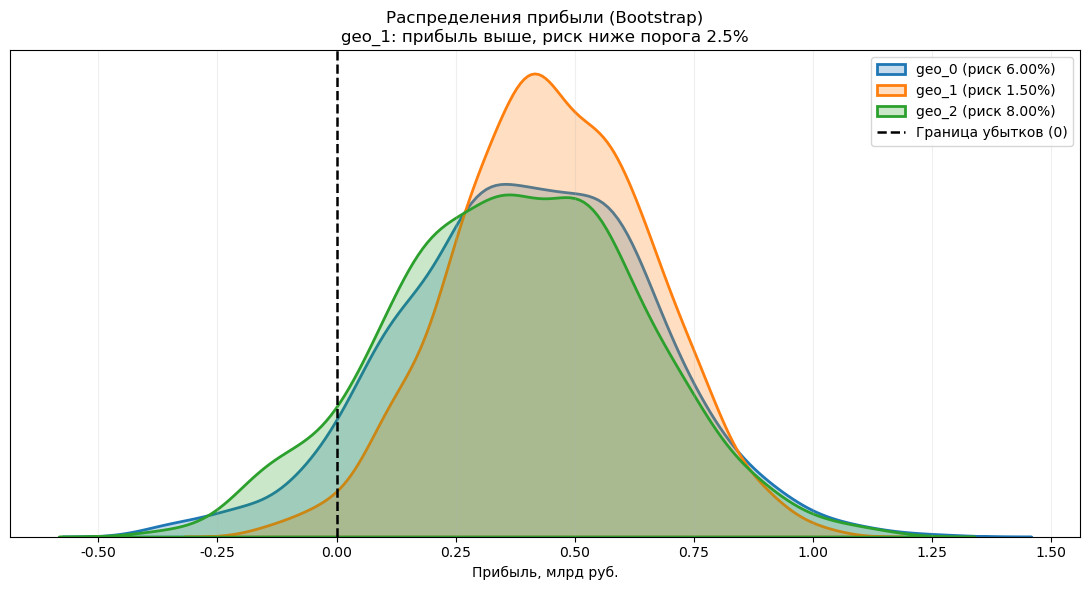

In [21]:


# График-история: распределения прибыли Bootstrap по регионам

risk_threshold = 0.025

plot_df = pd.DataFrame({
	"region": list(bootstrap_results.keys()),
	"mean_profit": [bootstrap_results[r]["mean_profit"] for r in bootstrap_results],
	"risk": [bootstrap_results[r]["risk_of_loss"] for r in bootstrap_results],
})

eligible = plot_df[plot_df["risk"] < risk_threshold]
if not eligible.empty:
	best_region = eligible.sort_values("mean_profit", ascending=False).iloc[0]["region"]
	title_conclusion = f"{best_region}: прибыль выше, риск ниже порога 2.5%"
else:
	best_region = plot_df.sort_values("mean_profit", ascending=False).iloc[0]["region"]
	title_conclusion = f"{best_region}: прибыль выше, но риск выше порога 2.5%"

fig, ax = plt.subplots(figsize=(11, 6))

for region in ["geo_0", "geo_1", "geo_2"]:
	sns.kdeplot(
		bootstrap_results[region]["profits"],
		fill=True,
		alpha=0.25,
		linewidth=2,
		label=f"{region} (риск {bootstrap_results[region]['risk_of_loss']:.2%})",
		ax=ax
	)

ax.axvline(0, color="black", linestyle="--", linewidth=1.8, label="Граница убытков (0)")
ax.set_title(f"Распределения прибыли (Bootstrap)\n{title_conclusion}")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e9:.2f}"))
ax.set_xlabel("Прибыль, млрд руб.")
ax.set_ylabel("")
ax.set_yticks([])  # плотность в цифрах не нужна — важна форма
ax.legend()
ax.grid(alpha=0.2)

save_plot("profit_distributions")
plt.show()

### Вывод по результатам Bootstrap

По результатам Bootstrap были получены следующие оценки:

- для `geo_1` средняя прибыль составила **452.05 млн руб.**, 95%-й доверительный интервал — от **61.68 млн руб.** до **845.34 млн руб.**, риск убытков — **1.50%**;
- для `geo_0` средняя прибыль составила **399.58 млн руб.**, 95%-й доверительный интервал — от **-110.47 млн руб.** до **897.46 млн руб.**, риск убытков — **6.00%**;
- для `geo_2` средняя прибыль составила **375.01 млн руб.**, 95%-й доверительный интервал — от **-144.77 млн руб.** до **888.39 млн руб.**, риск убытков — **8.00%**.

Наилучшие результаты показывает регион `geo_1`: он имеет максимальную среднюю прибыль и минимальный риск убытков, который ниже допустимого порога 2.5%.

Регионы `geo_0` и `geo_2` не подходят для разработки, так как вероятность убытков в них превышает допустимый уровень. Кроме того, нижние границы их 95%-х доверительных интервалов находятся в отрицательной области, что дополнительно указывает на повышенный риск.

Таким образом, единственным регионом, удовлетворяющим условию задачи и одновременно показывающим наибольшую среднюю прибыль, является `geo_1`.

## Итоговый вывод

В ходе проекта были последовательно выполнены все этапы исследования: проведена загрузка и проверка данных по трём регионам, обучены модели линейной регрессии, рассчитан безубыточный объём сырья, выполнен предварительный расчёт прибыли и проведена оценка рисков методом Bootstrap.

На этапе обучения моделей было установлено, что регион `geo_1` отличается наилучшим качеством предсказаний: для него получено минимальное значение RMSE. При этом регионы `geo_0` и `geo_2` показывали более высокие средние прогнозируемые запасы, но заметно уступали по точности модели.

Расчёт безубыточного объёма показал, что средний прогнозируемый запас ни в одном из регионов не достигает порогового значения **111.11 тыс. баррелей** на одну скважину. Однако этот результат не является окончательным, так как по условию задачи в разработку отбираются только 200 лучших скважин из 500.

Предварительный расчёт прибыли по отобранным скважинам показал положительный результат для всех трёх регионов. Однако для принятия решения этого недостаточно, поскольку необходимо учитывать риск убытков.

Окончательный выбор был сделан по результатам Bootstrap:
- `geo_1` — средняя прибыль **452.05 млн руб.**, риск убытков **1.50%**;
- `geo_0` — средняя прибыль **399.58 млн руб.**, риск убытков **6.00%**;
- `geo_2` — средняя прибыль **375.01 млн руб.**, риск убытков **8.00%**.

Согласно условию задачи, для разработки подходят только регионы, где вероятность убытков меньше **2.5%**. Этому критерию соответствует только регион `geo_1`. Кроме того, именно он показывает наибольшую среднюю прибыль среди допустимых вариантов.

**Рекомендация:** для разработки новых скважин следует выбрать регион **`geo_1`**, так как он сочетает максимальную среднюю прибыль и допустимый уровень риска.